# Lecture 2 — Class Exercise
# Bar Charts: World Happiness Report 2023

---

> **Your task:** Create **2 polished bar charts** using the World Happiness Report dataset.  
> **Push to:** `week02/lecture02_exercise.ipynb` in **your own GitHub repo** before the end of class.

---

### Rules (these will be checked in the model answer review next week)
1. Every bar chart **must have a zero baseline** — no exceptions (SWD p.51)
2. Every chart **must have an insight title**, not a topic title (SWD p.29)
3. Aim for **professional quality** — clean background, readable font, no clutter
4. Horizontal bars for long category names (SWD p.57)

---


## Setup — Run this cell first


In [1]:
import pandas as pd
import numpy as np

# World Happiness Report 2023 — representative data
# Source: https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2023

df = pd.read_csv('../data/world_happiness_2023.csv')
df.columns = ['Country','Region','Happiness_Score','GDP','Social_Support',
              'Life_Expectancy','Freedom','Generosity','Corruption']


print(f"Dataset: {len(df)} countries, {len(df.columns)} columns")
print(df.head())


Dataset: 63 countries, 9 columns
       Country                        Region  Happiness_Score     GDP  \
0      Finland                Western Europe            7.804  10.775   
1      Denmark                Western Europe            7.586  10.933   
2      Iceland                Western Europe            7.525  10.878   
3       Israel  Middle East and North Africa            7.473  10.527   
4  Netherlands                Western Europe            7.464  11.015   

   Social_Support  Life_Expectancy  Freedom  Generosity  Corruption  
0           0.954             71.9    0.949       0.142       0.179  
1           0.954             72.7    0.931       0.168       0.234  
2           0.983             72.5    0.961       0.260       0.150  
3           0.916             72.4    0.903       0.149       0.826  
4           0.939             72.4    0.879       0.240       0.296  


In [3]:
!pip install plotly
import plotly.express as px
import plotly.graph_objects as go

# Explore the dataset before you start
print("Regions in dataset:")
print(df['Region'].value_counts())
print("\nScore range:", df['Happiness_Score'].min(), "–", df['Happiness_Score'].max())
print("\nBottom 10 countries:")
print(df.nsmallest(10, 'Happiness_Score')[['Country','Region','Happiness_Score']])


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 10.1 MB/s  0:00:00 11.1 MB/s eta 0:00:01
Regions in dataset:
Region
Western Europe                  15
Latin America and Caribbean     13
Central and Eastern Europe       7
Sub-Saharan Africa               7
Middle East and North Africa     6
North America and ANZ            4
Southeast Asia                   4
South Asia                       4
East Asia                        3
Name: count, dtype: int64

Score range: 1.859 – 7.804

Bottom 10 countries:
        Country                        Region  Happiness_Score
60  Afghanistan                    South Asia            1.859
61      Lebanon  Middle East and North Africa            2.392
62     Zimbabwe            Sub-Saharan Africa            2.995
52     Ethiopia            Sub-Saharan Africa            3.564
53     Tanzania            Sub-Saharan Africa            3.698
48   Bangladesh                    South Asia            3.892
47        India                    South Asia

---
## Task 1 — Regional Comparison Bar Chart

**What to build:** A horizontal bar chart showing the **average happiness score by region**, sorted from highest to lowest.

**Requirements:**
- Horizontal orientation (category names are long)
- Sorted by score, descending (so the happiest region is at the top)
- Zero baseline on x-axis
- At least one design choice that goes beyond the Plotly default (colour, annotation, labels, etc.)
- An insight title that answers: *which region stands out and why does it matter?*

**Hint:** Use `df.groupby('Region')['Happiness_Score'].mean()` to compute the averages.


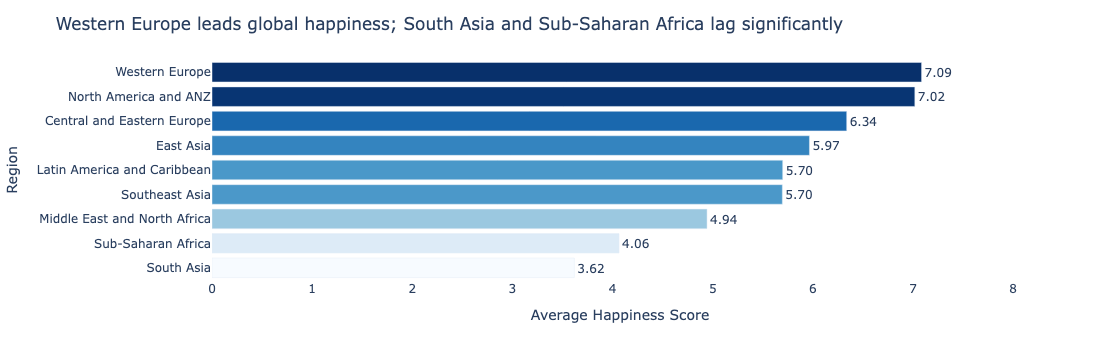

In [10]:
# Step 1: Compute regional averages (sorted high → low)
region_avg = (df.groupby('Region')['Happiness_Score']
              .mean()
              .reset_index()
              .sort_values('Happiness_Score', ascending=False))

# Step 2: Build horizontal bar chart
fig = px.bar(
    region_avg,
    x='Happiness_Score',
    y='Region',
    orientation='h',
    text='Happiness_Score',
    color='Happiness_Score',
    color_continuous_scale='Blues'
)

# Step 3: Styling for professional quality
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')

fig.update_layout(
    title="Western Europe leads global happiness; South Asia and Sub-Saharan Africa lag significantly",
    xaxis_title="Average Happiness Score",
    yaxis_title="Region",
    plot_bgcolor='white',
    coloraxis_showscale=False
)

# Step 4: Enforce zero baseline (critical requirement)
fig.update_xaxes(range=[0, region_avg['Happiness_Score'].max() * 1.15], zeroline=True)

# Step 5: Put highest value at the top (clean ranking view)
fig.update_yaxes(autorange='reversed')

fig.show()

---
## Task 2 — Bottom vs. Top: A Contrast Story

**What to build:** A bar chart that highlights the **gap between the happiest and least happy countries**, focusing on a specific insight.

**Requirements:**
- Show the **top 8 AND bottom 8 countries** together (16 bars total)
- Use **colour** to distinguish the two groups (not Plotly's default rainbow)
- Add a **visual separator or annotation** that emphasises the gap
- Insight title that tells the story of the gap

**Hint:** Use `pd.concat([df.nlargest(8,'Happiness_Score'), df.nsmallest(8,'Happiness_Score')])` to get both groups.

**Stretch goal:** Add a vertical reference line showing the global average.


Global average: 5.81


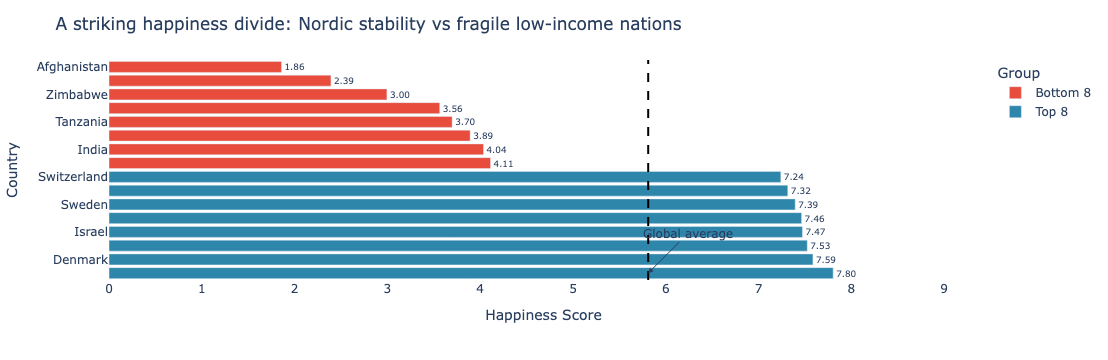

In [11]:
# Task 2: Top 8 vs. Bottom 8 contrast
# ------------------------------------

# Step 1: Get top and bottom countries
top8 = df.nlargest(8, 'Happiness_Score').copy()
top8['Group'] = 'Top 8'
bottom8 = df.nsmallest(8, 'Happiness_Score').copy()
bottom8['Group'] = 'Bottom 8'

combined = pd.concat([bottom8, top8]).sort_values('Happiness_Score')
global_avg = df['Happiness_Score'].mean()
print(f"Global average: {global_avg:.2f}")

# Step 2: Build your chart
# YOUR CODE HERE

import plotly.express as px

fig = px.bar(
    combined,
    x='Happiness_Score',
    y='Country',
    orientation='h',
    color='Group',
    text='Happiness_Score',
    color_discrete_map={
        'Top 8': '#2E86AB',      # calm blue
        'Bottom 8': '#E74C3C'    # strong red
    }
)

# Show values on bars
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')

# Layout styling
fig.update_layout(
    title="A striking happiness divide: Nordic stability vs fragile low-income nations",
    xaxis_title="Happiness Score",
    yaxis_title="Country",
    plot_bgcolor='white',
    legend_title="Group"
)

# Zero baseline (required rule)
fig.update_xaxes(range=[0, combined['Happiness_Score'].max() * 1.2], zeroline=True)

# Add global average reference line (stretch goal)
fig.add_vline(
    x=global_avg,
    line_width=2,
    line_dash="dash",
    line_color="black"
)

fig.add_annotation(
    x=global_avg,
    y=combined['Country'].iloc[-1],
    text="Global average",
    showarrow=True,
    arrowhead=2,
    ax=40,
    ay=-40
)

# Improve ordering for readability
fig.update_yaxes(autorange='reversed')

fig.show()


---
## Done? Stretch Goal

If you finish both tasks with time to spare, try this:

**Task 3 (stretch):** Build a **grouped bar chart** comparing 2 sub-factors (e.g. `GDP_per_capita` and `Freedom`) across the 5 most populated regions. Use colour meaningfully and write an insight title.

Regions to include: `'Western Europe'`, `'Latin America'`, `'East Asia'`, `'Sub-Saharan Africa'`, `'South Asia'`


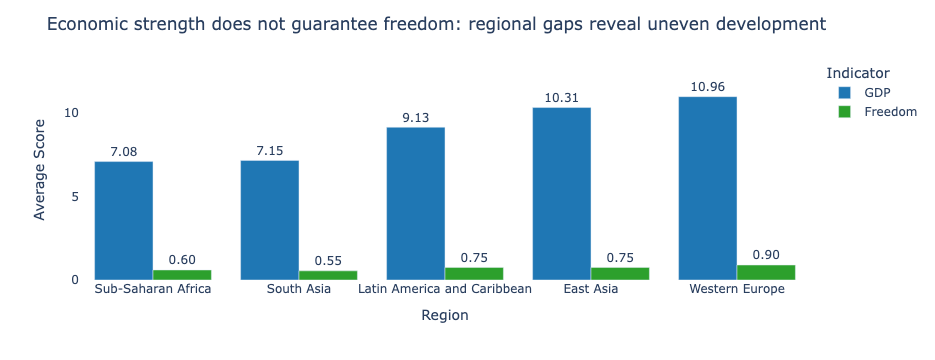

In [12]:
# Stretch goal — grouped bar chart
# YOUR CODE HERE
# ------------------------------------
# Step 1: Filter selected regions
# ------------------------------------
regions = [
    'Western Europe',
    'Latin America and Caribbean',
    'East Asia',
    'Sub-Saharan Africa',
    'South Asia'
]

df_filtered = df[df['Region'].isin(regions)].copy()

# ------------------------------------
# Step 2: Aggregate mean values
# ------------------------------------
region_compare = df_filtered.groupby('Region')[['GDP', 'Freedom']].mean().reset_index()

# Sort for better readability
region_compare = region_compare.sort_values('GDP')

# ------------------------------------
# Step 3: Convert to long format for grouped bar chart
# ------------------------------------
df_melted = region_compare.melt(
    id_vars='Region',
    value_vars=['GDP', 'Freedom'],
    var_name='Indicator',
    value_name='Score'
)

# ------------------------------------
# Step 4: Create grouped bar chart
# ------------------------------------
import plotly.express as px

fig = px.bar(
    df_melted,
    x='Region',
    y='Score',
    color='Indicator',
    barmode='group',
    text='Score',
    color_discrete_map={
        'GDP': '#1f77b4',      # strong blue
        'Freedom': '#2ca02c'   # green
    }
)

# ------------------------------------
# Step 5: Styling (professional quality)
# ------------------------------------
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')

fig.update_layout(
    title="Economic strength does not guarantee freedom: regional gaps reveal uneven development",
    xaxis_title="Region",
    yaxis_title="Average Score",
    plot_bgcolor='white',
    legend_title="Indicator"
)

# Zero baseline requirement
fig.update_yaxes(range=[0, df_melted['Score'].max() * 1.2], zeroline=True)

fig.show()
